In [ ]:
from google.colab import drive

# Mount personal Google Drive to the vm
drive.mount('/content/drive')

# Unzip drive: no overwrite and quiet output mode
!unzip -n -q '/content/drive/MyDrive/archive_training.zip' -d /content/

Mounted at /content/drive


## Custom PyTorch Dataset for Saliency Mapping
This section defines the SaliencyDataset, a custom PyTorch class inherited from torch.utils.data.Dataset. This class is responsible for systematically loading, pairing, and processing our data from the storage directories before feeding it into the neural network.
* Robust File Filtering and Pairing: The initialization method scans the provided image and ground truth directories. It safely filters out irrelevant file formats and OS-specific hidden files. Using a fast set-based lookup, it automatically pairs the RGB input images (.jpg or .jpeg) with their corresponding ground truth saliency maps (.png) by matching their base filenames.
* Data Retrieval and Formatting (__getitem__): When the DataLoader requests a specific batch index, this function reads the paired files from the disk. It ensures the input image is strictly loaded in RGB format (3 channels) and the ground truth map is loaded in Grayscale format (L mode, 1 channel).
* On-the-Fly Transformations: If any preprocessing or augmentation pipelines (defined via transform_img and transform_gt) are passed during instantiation, they are applied directly to the images and maps at load time. This ensures our tensors are properly resized, normalized, and augmented before training.

In [ ]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

class SaliencyDataset(Dataset):
    # Loads images and ground truths masks from the dataset. Automatically pairs them using filenames
    def __init__(self, images_dir, gt_dir, transform_img=None, transform_gt=None):
        # images_dir: path to directory with input images
        # gt_dir: path to directory with ground truth masks
        # transform_img (optional): pytorch transforms over input
        # transform_gt (optional): pytorch transforms over ground truth
        self.images_dir = images_dir
        self.gt_dir = gt_dir
        self.transform_img = transform_img
        self.transform_gt = transform_gt

        # Acceptable extensions for input JPEGs and ground truth PNGs
        valid_img_exts = ('.jpg', '.jpeg')
        valid_gt_exts = ('.png',)

        # Read files, check extensions, and filter out macOS hidden files
        img_files = sorted([
            f for f in os.listdir(images_dir)
            if f.lower().endswith(valid_img_exts) and not f.startswith('._')
        ])
        gt_files = sorted([
            f for f in os.listdir(gt_dir)
            if f.lower().endswith(valid_gt_exts) and not f.startswith('._')
        ])

        print(f"Found {len(img_files)} images (.jpg) and {len(gt_files)} maps (.png).")

        self.paired_files = []

        # Convert ground truth list into a set for O(1) search in pairing
        gt_files_set = set(gt_files)

        #Pair image with ground truth
        for img_f in img_files:
            # Extract filename without extension, then add .png
            base_name = os.path.splitext(img_f)[0]
            expected_gt = f"{base_name}.png"

            # If the map exists, register the pair
            if expected_gt in gt_files_set:
                self.paired_files.append((img_f, expected_gt))

        print(f"Completed pairings: {len(self.paired_files)}")

    def __len__(self):
        # Number of img-gt pairs
        return len(self.paired_files)

    def __getitem__(self, idx):
        # Retrieve image and truth mask at the given index; returns a tuple (either images or tensors)
        img_name, gt_name = self.paired_files[idx]

        # Rebuild full file paths
        img_path = os.path.join(self.images_dir, img_name)
        gt_path = os.path.join(self.gt_dir, gt_name)

        # Force conversion to RGB (3 channels) for the image and to greyscale (1 channel) for the ground truth
        image = Image.open(img_path).convert("RGB")
        ground_truth = Image.open(gt_path).convert("L")

        # Apply any defined transforms
        if self.transform_img:
            image = self.transform_img(image)
        if self.transform_gt:
            ground_truth = self.transform_gt(ground_truth)

        return image, ground_truth

# Data Preprocessing and DataLoader Initialization

In this section, we establish the data pipeline required to train and evaluate the deep learning model. The process is broken down into defining transformations, instantiating the datasets, and configuring hardware-optimized data loaders.
* Data Transformations & Augmentation:
  * Ground Truth Maps (transform_gt): Maps are resized to a standard 224x224 resolution and converted directly into PyTorch tensors.
  * Input Images (transform_img): In addition to resizing, the training images undergo spatial data augmentation using ColorJitter (randomly adjusting brightness, contrast, saturation, and hue). This technique helps prevent overfitting and improves the model's robustness to varying lighting conditions. Finally, the images are normalized using the standard ImageNet dataset statistics.

* Dataset Instantiation and Splitting: We utilize our custom SaliencyDataset class to load the automatically paired images and ground truth maps from their respective directories. To ensure a rigorous and unbiased evaluation, the initial validation directory is split exactly in half using random_split, creating two entirely distinct subsets: one for continuous validation during training and one for the final testing phase.

* Optimized DataLoaders: The DataLoader instances are configured to maximize computational efficiency, specifically tailored for environments with limited VRAM like Google Colab. We define a micro-batch size of 2 (which will be coupled with gradient accumulation during the training loop), utilize 2 worker processes for parallel data loading, and enable pin_memory=True to accelerate CPU-to-GPU data transfers

In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader


# Fixed input size expected by the NN
IMG_SIZE = (224, 224)

# TRANSFORMS
# Transforms for ground truth masks
# Resize and convert to tensor. No color variation or normalization, need to preserve pixel values
transform_gt = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor()
])

# Transforms for input images
transform_img = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    # Data augmentation: randomly shift brightness, contrast, saturation, hue
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    # Convert image to pytorch float tensor
    transforms.ToTensor(),
    # Normalize the tensor using standard ImageNet mean and std dev
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# PATHS
# Directory paths for the extracted training and validation/test datasets
# Fixed: try either /content/images/images/train or /content/archive/images/images/train
percorso_stimoli_train = '/content/archive/images/images/train'
percorso_mappe_train = '/content/archive/maps/train'

percorso_stimoli_valtest = '/content/archive/images/images/val'
percorso_mappe_valtest = '/content/archive/maps/val'

# DATASET CREATION
# Instantiate training dataset with our custom class
train_dataset = SaliencyDataset(
    images_dir=percorso_stimoli_train,
    gt_dir=percorso_mappe_train,
    transform_img=transform_img,
    transform_gt=transform_gt
)

# Instatiate combined test and validation dataset
val_test_dataset = SaliencyDataset(
    images_dir=percorso_stimoli_valtest,
    gt_dir=percorso_mappe_valtest,
    transform_img=transform_img,
    transform_gt=transform_gt
)

# NEW DATASET SPLIT
# Compute sizes to split 50/50
total_val_test = len(val_test_dataset)
val_size = total_val_test // 2
test_size = total_val_test - val_size

# Randomly split into independent validation and test sets
val_dataset, test_dataset = random_split(val_test_dataset, [val_size, test_size])

print("\n--- Riepilogo Dataset ---")
print(f"Immagini di Training: {len(train_dataset)}")
print(f"Immagini di Validation: {len(val_dataset)}")
print(f"Immagini di Test: {len(test_dataset)}\n")

# DATALOADER CREATION
# Configure for Colab hardware limits and gradient accumulation
micro_batch_size = 2    # Prevent out of memory on the GPU
num_workers = 2         # Fetch data in parallel on 2 GPUs
pin_memory = True       # Page lock memory, faster CPU-GPU transfer

# Training dataloader, include shuffling to avoid learning the input sequence
train_loader = DataLoader(
    train_dataset,
    batch_size=micro_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

# Validation dataloader, no need to shuffle
val_loader = DataLoader(
    val_dataset,
    batch_size=micro_batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

# Test dataloader, also no shuffle
test_loader = DataLoader(
    test_dataset,
    batch_size=micro_batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

Found 10000 images (.jpg) and 10000 maps (.png).
Completed pairings: 10000
Found 5000 images (.jpg) and 5000 maps (.png).
Completed pairings: 5000

--- Riepilogo Dataset ---
Immagini di Training: 10000
Immagini di Validation: 2500
Immagini di Test: 2500



# Swin-Transformer Encoder and Convolutional Decoder
This section defines the core neural network architecture, SwinSaliencyModel, which employs a hybrid approach. It combines the global context awareness of Vision Transformers with the precise spatial localization capabilities of Convolutional Neural Networks (CNNs).

* The Encoder (Swin-Tiny Backbone): The feature extractor leverages a pre-trained Swin Transformer (swin_t). The encoder processes the input image through four hierarchical stages, progressively reducing the spatial resolution down to a central bottleneck while expanding the feature channel depth (up to 768 channels). Importantly, during the forward pass, a .permute() operation is applied to restructure the transformer's native output tensors—from (Batch, Height, Width, Channels) into the (Batch, Channels, Height, Width) format—making them compatible with standard PyTorch 2D convolutional layers.
* The Decoder and Skip Connections: The decoder is designed to reconstruct the spatial resolution needed for pixel-wise prediction. It utilizes bilinear upsampling iteratively combined with skip connections. These connections directly concatenate the high-resolution, localized features from the early encoder stages with the deeply processed, semantically rich features of the decoder, preventing the loss of fine spatial details during upsampling.
* Regularization via Spatial Dropout: To enhance the model's generalization capabilities, each custom decoding block incorporates a 2D Spatial Dropout layer (nn.Dropout2d(p=0.2)). Unlike standard dropout which drops individual neurons, spatial dropout randomly zeroes out 20% of entire feature channels, effectively forcing the network to rely on a broader variety of visual cues rather than over-depending on a few specific feature maps.
* Final Output Layer: After three decoding stages, a final ‭$4\times$‬‭‬ bilinear upsampling operation restores the feature map exactly to the original input resolution. Finally, a ‭$1 \times 1$‬‭‬ convolution compresses the tensor into a single channel, and a Sigmoid activation function squashes the pixel values into a continuous probability range between 0 and 1, yielding the final saliency map.

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class SwinSaliencyModel(nn.Module):
    def __init__(self):
        super(SwinSaliencyModel, self).__init__()

        # Load the Swin-Tiny model pretrained on ImageNet
        swin = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)

        # ENCODER
        # In the Swin of pytorch, block output is in the form (Batch, Height, Width, Channels)
        # Extract features at 4 different scales

        # Stage 1: Output (B, H/4, W/4, 96)
        self.stage1 = nn.Sequential(swin.features[0], swin.features[1])

        # Stage 2: Output (B, H/8, W/8, 192)
        self.stage2 = swin.features[2:4]

        # Stage 3: Output (B, H/16, W/16, 384)
        self.stage3 = swin.features[4:6]

        # Stage 4 (Bottleneck): Output (B, H/32, W/32, 768)
        self.stage4 = swin.features[6:8]

        # Decoder support function
        def dec_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
                nn.Dropout2d(p=0.2), # <--- SPATIAL DROPOUT: randomly switch off 20% of channels
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )

        # DECODER
        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # 768 (bottleneck) + 384 (stage3) = 1152
        self.dec3 = dec_block(1152, 384)

        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # 384 (dec3) + 192 (stage2) = 576
        self.dec2 = dec_block(576, 192)

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        # 192 (dec2) + 96 (stage1) = 288
        self.dec1 = dec_block(288, 96)

        # Final x4 upsample to return to image initial size
        self.up_final = nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)

        # Output layer
        self.final_conv = nn.Conv2d(96, 1, kernel_size=1)

    def forward(self, x):

        e1_hwc = self.stage1(x)
        e1 = e1_hwc.permute(0, 3, 1, 2)

        e2_hwc = self.stage2(e1_hwc)
        e2 = e2_hwc.permute(0, 3, 1, 2)

        e3_hwc = self.stage3(e2_hwc)
        e3 = e3_hwc.permute(0, 3, 1, 2)

        b_hwc = self.stage4(e3_hwc)
        b = b_hwc.permute(0, 3, 1, 2)


        d3 = self.up3(b)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        # Map generation
        out = self.up_final(d1)
        out = torch.sigmoid(self.final_conv(out))
        return out

# Custom Hybrid Loss Function and Evaluation Metrics
This section defines the mathematical core of the training process: the custom KLCCHybridLoss module used to optimize the network, alongside two standalone functions for continuous metric tracking.

* The KLCCHybridLoss Formulation: Saliency prediction requires both the statistical distribution and the structural layout of the predictions to match the ground truth. To achieve this, the loss function combines two distinct mathematical penalty systems:

    * Kullback-Leibler Divergence (KL): First, the tensors are flattened and normalized so their pixel values sum to 1, treating them as 1D probability distributions. The KL divergence then measures the cross-entropy difference between the predicted distribution and the ground truth. A tiny ‭$\epsilon$‬ (1e-7) is added to prevent mathematical instability (division by zero or ‭$\log(0)$‬‭‬‭‬‭‬).
    
    * Pearson Correlation Coefficient (CC): This component evaluates the linear, structural relationship between the maps. It centers the data by subtracting the mean, then calculates the covariance divided by the product of the standard deviations. Because PyTorch optimizers strictly minimize values, the CC loss is formulated as ‭$1 - CC$‬‭‬, forcing the optimizer to push the correlation as close to 1.0 as possible.
    
    * Final Combination: The total loss is computed as ‭$Total Loss = KL + \lambda (1 - CC)$‬‭‬‭‬‭‬‭‬‭‬‭‬, where ‭$\lambda$‬ (cc_weight) is a modulating factor set to 1.0 by default, balancing the gradients equally between distribution matching and structural correlation.

*	Standalone Metric Functions:

    * calculate_metrics_continuous: Replicates the Pearson CC logic but completely detaches it from the computational graph, returning a clean Python float used exclusively for logging and plotting during the validation and test phases.

    * compute_sim: Calculates the Similarity Metric (SIM), also known as histogram intersection. After normalizing the flattened maps, it sums the element-wise minimums: ‭$\sum \min(Pred, GT)$‬‭‬‭‬‭‬‭‬ ‭‬‭‬. This intuitively measures the exact percentage of overlapping probability mass between the predicted attention and human fixations.

In [ ]:
import torch
import torch.nn as nn

class KLCCHybridLoss(nn.Module):
    # Custom hybrid loss for saliency map generation

    def __init__(self, cc_weight=1.0):
        # cc_weight: float, modulates importance of CC wrt KL. 1.0 means they're equally important
        super(KLCCHybridLoss, self).__init__()
        self.cc_weight = cc_weight
        self.epsilon = 1e-7     # Correct denominators and logs to avoid division by zero

    def forward(self, preds, gts):
        # Forward pass for the loss function
        # preds = predicted saliency masks of shape (B, 1, H, W)
        # gts = equivalent for ground truth

        # SETUP
        # For every image in the batch turn the tensor in a 1D vector, overall shape becomes (B, H*W)
        preds_flat = preds.view(preds.size(0), -1)
        gts_flat = gts.view(gts.size(0), -1)

        # KL-DIVERGENCE
        # Normalize in a distribution that sums to 1
        preds_norm = preds_flat / (preds_flat.sum(dim=1, keepdim=True) + self.epsilon)
        gts_norm = gts_flat / (gts_flat.sum(dim=1, keepdim=True) + self.epsilon)

        # Compute divergence as: sum( gts * log(gts / preds) )
        kl_div = torch.sum(gts_norm * torch.log((gts_norm + self.epsilon) / (preds_norm + self.epsilon)), dim=1)
        # Average over batch
        kl_loss = torch.mean(kl_div)

        # PEARSON CORRELATION
        # Subtract the means
        preds_mean = preds_flat - preds_flat.mean(dim=1, keepdim=True)
        gts_mean = gts_flat - gts_flat.mean(dim=1, keepdim=True)

        # Compute covariance and std dev
        covariance = torch.sum(preds_mean * gts_mean, dim=1)
        std_preds = torch.sqrt(torch.sum(preds_mean**2, dim=1))
        std_gts = torch.sqrt(torch.sum(gts_mean**2, dim=1))

        # Compute base CC (add epsilon correction)
        cc = covariance / (std_preds * std_gts + self.epsilon)
        cc_mean = torch.mean(cc)

        # Loss CC: we want the CC to go to 1, so we minimize 1-CC
        cc_loss = 1.0 - cc_mean

        # WEIGHTED COMBINATION OF KL AND CC
        total_loss = kl_loss + (self.cc_weight * cc_loss)

        return total_loss

def calculate_metrics_continuous(preds, gts):

    # Returns the mean CC value for the given batch
    # Flatten spatial dimensions
    preds_flat = preds.view(preds.size(0), -1)
    gts_flat = gts.view(gts.size(0), -1)

    # Subtract mean from every map
    preds_mean = preds_flat - preds_flat.mean(dim=1, keepdim=True)
    gts_mean = gts_flat - gts_flat.mean(dim=1, keepdim=True)

    # Compute covariance (numerator)
    covariance = torch.sum(preds_mean * gts_mean, dim=1)

    # Compute std devs (denominator)
    std_preds = torch.sqrt(torch.sum(preds_mean**2, dim=1))
    std_gts = torch.sqrt(torch.sum(gts_mean**2, dim=1))

    # Compute CC
    cc = covariance / (std_preds * std_gts + 1e-7)

    # Return CC mean in the batch
    return torch.mean(cc).item()


def compute_sim(preds, gts):
    # Similarity (SIM) metric: overlap between two probability distributions (1.0 is perfect overlap, 0.0 is no overlap)

    # Flatten the 2D spatial maps into 1D arrays for each image in the batch
    preds_flat = preds.view(preds.size(0), -1)
    gts_flat = gts.view(gts.size(0), -1)

    # Normalize both maps so that their pixels sum to exactly 1.0
    preds_norm = preds_flat / (preds_flat.sum(dim=1, keepdim=True) + 1e-7)
    gts_norm = gts_flat / (gts_flat.sum(dim=1, keepdim=True) + 1e-7)

    # Histogram intersection
    sim = torch.sum(torch.min(preds_norm, gts_norm), dim=1)
    return torch.mean(sim).item()

# Model Initialization and Training Loop
This section executes the main training pipeline, systematically orchestrating model optimization, hardware management, and continuous performance validation over multiple epochs.

* Model and Optimizer Initialization: The script first allocates the SwinSaliencyModel to the active hardware device. The network is optimized using the Adam optimizer with a learning rate of 1e-5 and a slight weight decay (1e-4) to enforce L2 regularization, which helps prevent the model from memorizing the training data. The custom KLCCHybridLoss is instantiated as the primary criterion.

* Gradient Accumulation Strategy: Due to the VRAM constraints often encountered when training Vision Transformers on Colab, the model employs Gradient Accumulation. The network processes micro-batches of 2 images, computes the loss, scales it down (scaled_loss = loss / accumulation_steps), and accumulates the gradients in memory using .backward(). The optimizer only updates the network weights (optimizer.step()) after 4 forward passes, perfectly simulating a macro-batch size of 8 while keeping memory usage low.

* Training and Validation Phases:
    
    * During the Training Phase (model.train()), the network actively learns by computing gradients and updating its weights, while tracking both the KL loss and Pearson CC.
    
    * During the Validation Phase (model.eval() and torch.no_grad()), the gradient computation engine is completely disabled to save memory and processing power. The model evaluates the unseen validation subset to verify its generalization capabilities.
    
    * Early Stopping and Model Checkpointing: To maximize efficiency and prevent overfitting, the training loop incorporates an Early Stopping mechanism. At the end of each epoch, the script checks if the val_loss has reached a new minimum. If it has, the model's optimal state (state_dict) is saved securely to Google Drive. If the validation loss fails to improve for 5 consecutive epochs (patience = 5), the training is automatically halted

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate model, loss and send them to the device
model = SwinSaliencyModel().to(device)
criterion = KLCCHybridLoss(cc_weight=1.0)
# Adam optimizer to manage weight updates (standard starting learning rate and small weight decay)
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 154MB/s] 


In [7]:
# HYPERPARAMETERS
# Training parameters and gradient accumulation
epochs = 20
# Accumulate the resulting gradients for 4 steps
accumulation_steps = 4  # micro_batch(2) * steps(4) = resulting batch size 8
# Early stopping if no improvement is seen for 5 steps
patience = 5
patience_counter = 0
best_val_loss = float('inf')
percorso_salvataggio = '/content/drive/MyDrive/visiontransFinal.pth'

# Metrics for graphs
train_losses, val_losses = [], []
train_ccs, val_ccs = [], []

print("Starting Training...\n")

for epoch in range(epochs):
    # TRAINING PHASE
    model.train()
    running_loss = 0.0
    running_cc = 0.0

    # Reset old gradients before the loop
    optimizer.zero_grad()

    for i, (images, gts) in enumerate(train_loader):
        # Move data to the GPU
        images, gts = images.to(device), gts.to(device)

        # Forward pass for prediction
        outputs = model(images)
        # Forward pass for loss
        loss = criterion(outputs, gts)

        # Divide loss by accumulation steps
        scaled_loss = loss / accumulation_steps
        # Backward pass to compute gradients for each weight
        scaled_loss.backward()

        # Monitor the loss for graphs
        running_loss += loss.item()

        # Compute CC to track progress
        batch_cc = calculate_metrics_continuous(outputs, gts)
        running_cc += batch_cc

        # Once we've reached the wanted steps or finished the batches, apply the update
        if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
            optimizer.step()
            optimizer.zero_grad() # Clear for the next macro batch

        # Show progress less frequently
        if (i + 1) % (10 * accumulation_steps) == 0:
            print(f"  -> Epoch [{epoch+1}/{epochs}], Macro-Batch [{(i+1)//accumulation_steps}/{(len(train_loader))//accumulation_steps}], "
                  f"Loss (KL): {loss.item():.4f}, CC: {batch_cc:.4f}")

    # Compute average metrics for the entire training epoch
    epoch_train_loss = running_loss / len(train_loader)
    epoch_train_cc = running_cc / len(train_loader)
    train_losses.append(epoch_train_loss)
    train_ccs.append(epoch_train_cc)

    # VALIDATION PHASE
    # Lock weight updates during this phase
    model.eval()
    val_running_loss = 0.0
    val_running_cc = 0.0

    # Turn off gradient computation and storing
    with torch.no_grad():
        for val_images, val_gts in val_loader:
            val_images, val_gts = val_images.to(device), val_gts.to(device)

            # Forward passes
            val_outputs = model(val_images)
            val_loss = criterion(val_outputs, val_gts)

            val_running_loss += val_loss.item()
            val_batch_cc = calculate_metrics_continuous(val_outputs, val_gts)
            val_running_cc += val_batch_cc

    # Compute average metrics for the validation epoch
    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_cc = val_running_cc / len(val_loader)
    val_losses.append(epoch_val_loss)
    val_ccs.append(epoch_val_cc)

    print(f"\n*** Epoch Values [{epoch+1}/{epochs}] ***")
    print(f"Train Loss: {epoch_train_loss:.4f} | Train CC: {epoch_train_cc:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f}   | Val CC: {epoch_val_cc:.4f}")

    # EARLY STOPPING
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # Only save the model weights, not the whole class
        torch.save(model.state_dict(), percorso_salvataggio)
        print(f"--> [Improvement] Model saved in: {percorso_salvataggio}\n")
    else:
        patience_counter += 1
        print(f"--> [No Improvement] Patience: {patience_counter} / {patience}\n")

        if patience_counter >= patience:
            print(f"!!! EARLY STOPPING in epoch {epoch+1} !!!")
            break

print("Training finished!")

Starting Training...

  -> Epoch [1/20], Macro-Batch [10/1250], Loss (KL): 1.3792, CC: 0.3350
  -> Epoch [1/20], Macro-Batch [20/1250], Loss (KL): 1.2223, CC: 0.6145
  -> Epoch [1/20], Macro-Batch [30/1250], Loss (KL): 1.2143, CC: 0.7254
  -> Epoch [1/20], Macro-Batch [40/1250], Loss (KL): 1.5138, CC: 0.5477
  -> Epoch [1/20], Macro-Batch [50/1250], Loss (KL): 0.9277, CC: 0.7086
  -> Epoch [1/20], Macro-Batch [60/1250], Loss (KL): 1.1412, CC: 0.6767
  -> Epoch [1/20], Macro-Batch [70/1250], Loss (KL): 1.4814, CC: 0.5913
  -> Epoch [1/20], Macro-Batch [80/1250], Loss (KL): 0.8597, CC: 0.7685
  -> Epoch [1/20], Macro-Batch [90/1250], Loss (KL): 1.1122, CC: 0.5980
  -> Epoch [1/20], Macro-Batch [100/1250], Loss (KL): 1.6917, CC: 0.5711
  -> Epoch [1/20], Macro-Batch [110/1250], Loss (KL): 0.5723, CC: 0.8206
  -> Epoch [1/20], Macro-Batch [120/1250], Loss (KL): 0.6964, CC: 0.7541
  -> Epoch [1/20], Macro-Batch [130/1250], Loss (KL): 0.8643, CC: 0.6772
  -> Epoch [1/20], Macro-Batch [140/12

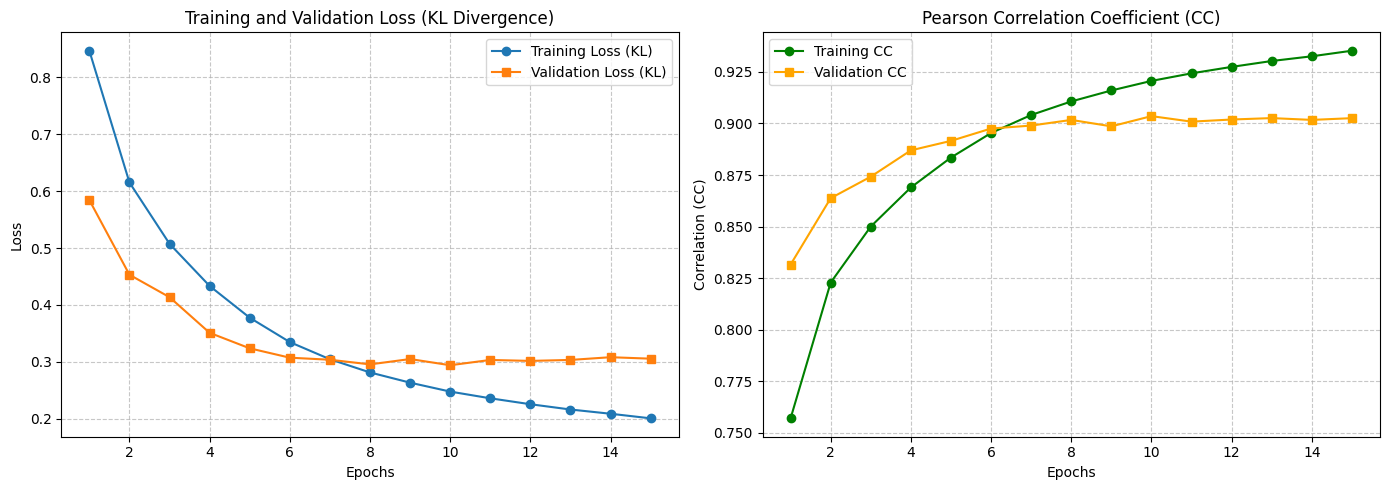

In [8]:
import matplotlib.pyplot as plt

# In case of early stopping
actual_epochs = len(train_losses)
plt.figure(figsize=(14, 5))

# Loss plot (KL Divergence, lower = better) to check for overfitting
plt.subplot(1, 2, 1)
plt.plot(range(1, actual_epochs + 1), train_losses, label='Training Loss (KL)', marker='o')
plt.plot(range(1, actual_epochs + 1), val_losses, label='Validation Loss (KL)', marker='s')
plt.title('Training and Validation Loss (KL Divergence)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Correlation plot (CC, higher = better)
plt.subplot(1, 2, 2)
plt.plot(range(1, actual_epochs + 1), train_ccs, label='Training CC', marker='o', color='green')
plt.plot(range(1, actual_epochs + 1), val_ccs, label='Validation CC', marker='s', color='orange')
plt.title('Pearson Correlation Coefficient (CC)')
plt.xlabel('Epochs')
plt.ylabel('Correlation (CC)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust spacing
plt.tight_layout()
plt.show()

In [9]:
import torch

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define model with same settings used for the training
model_loaded = SwinSaliencyModel()

# File saving path
percorso_salvataggio = '/content/drive/MyDrive/visiontransFinal.pth'

# Load the weight
# map_location=device to avoid errors if we trained on GPU and reload on CPU
model_loaded.load_state_dict(torch.load(percorso_salvataggio, map_location=device))

# Move model to device and lock it in inference mode
model_loaded = model_loaded.to(device)
model_loaded.eval()

print("Model successfully loaded! Ready for inference.")

Model successfully loaded! Ready for inference.


# Inference Pipeline: Multi-Scale TTA and Dynamic Post-Processing
This section executes the rigorous final inference and evaluation pipeline, structured into two distinct phases to ensure objective testing without data leakage. It employs advanced inference techniques to maximize the structural accuracy and smoothness of the generated saliency maps.

* Phase 1: Hyperparameter Grid Search (Validation Set)

	* Multi-Scale Test-Time Augmentation (TTA): To make the predictions robust to scale variations, the input images are processed at three different resolutions (0.8x, 1.0x, and 1.2x). For each scale, the model evaluates both the original image and a horizontally flipped version, fusing the results. When interpolating the scales, the spatial dimensions are strictly rounded to multiples of 32. This prevents shape mismatch errors during the decoder's skip-connection concatenations, as the Swin-Transformer bottleneck reduces the spatial resolution by a factor of 32.

    * Gaussian Blur Grid Search: Saliency maps often require smoothing to accurately mimic the continuous distribution of human eye fixations. Instead of guessing the smoothing parameters, the script performs a dynamic grid search over various Gaussian Blur configurations (testing multiple kernel_size and sigma pairs) directly on the TTA predictions. The configuration that yields the highest Pearson Correlation Coefficient (CC) on the validation set is selected as the absolute best.

* Phase 2: Rigorous Final Evaluation (Test Set)

    * Frozen Parameters: Moving to the completely independent test set, the model applies the exact same TTA strategy but strictly locks in the best_kernel and best_sigma found during Phase 1.

    * Final Metrics Calculation: The final smoothed predictions are evaluated against the ground truth test maps. The script calculates and outputs the definitive performance metrics: the overall Hybrid Loss, the Pearson Correlation Coefficient (CC), and the Similarity Metric (SIM)

In [10]:
# INFERENCE AND FINAL TEST
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF


print("PHASE 1: Searching for optimal Blur parameters on the Validation Set...")

# Define scale factors for the multi-scale TTA (zoomed out, original, zoomed it)
scales = [0.8, 1.0, 1.2]

# Grid with hyperparameters to be tested: (kernel_size, sigma)
# Kernel must be an odd number
blur_configs = [
    (3, 0.5), (3, 1.0),
    (5, 1.0), (5, 1.5),
    (7, 1.5), (7, 2.0),
    (9, 2.0)
]

# Accumulate the CC for every configuration
val_ccs_grid = {config: 0.0 for config in blur_configs}

# Disable gradient calculation to save memory during inference
with torch.no_grad():
    for images, gts in val_loader:
        images, gts = images.to(device), gts.to(device)
        b, c, h, w = images.size()

        # Empty tensor: accumulate predictions from all 6 variations (3 scales, 2 flips)
        ensemble_preds = torch.zeros((b, 1, h, w), device=device)

        # Compute base prediction with TTA on current batch
        for scale in scales:
            if scale != 1.0:
                # Need image dimensions divisible by 32 for the bottleneck
                scaled_h = int(round((h * scale) / 32.0)) * 32
                scaled_w = int(round((w * scale) / 32.0)) * 32
                images_scaled = F.interpolate(images, size=(scaled_h, scaled_w), mode='bilinear', align_corners=False)
            else:
                images_scaled = images

            # Predict on standard img, flipped img and average the predictions
            pred_orig = model_loaded(images_scaled)
            pred_flipped = model_loaded(torch.flip(images_scaled, dims=[3]))
            pred_fused = (pred_orig + torch.flip(pred_flipped, dims=[3])) / 2.0

            # If the image was scaled, resize the prediction up to original (h,w) before adding it to the pool
            if scale != 1.0:
                pred_fused = F.interpolate(pred_fused, size=(h, w), mode='bilinear', align_corners=False)

            ensemble_preds += pred_fused

        # Average by number of scales used
        outputs_base = ensemble_preds / len(scales)

        # Test all blurring configurations directly on the validation set
        for k, s in blur_configs:
            outputs_blurred = TF.gaussian_blur(outputs_base, kernel_size=[k, k], sigma=[s, s])
            # Force all pixels back in the right value range
            outputs_blurred = torch.clamp(outputs_blurred, 0.0, 1.0)

            # Compute CC for this blur and sum it
            batch_cc = calculate_metrics_continuous(outputs_blurred, gts)
            val_ccs_grid[(k, s)] += batch_cc

# Find the blur configuration with highest CC score
best_cc = -1
best_kernel = 5
best_sigma = 1.0

print("Output Grid Research:")
for config in blur_configs:
    avg_cc = val_ccs_grid[config] / len(val_loader)
    print(f" -> Kernel {config[0]}x{config[0]}, Sigma {config[1]:.1f} | Val CC: {avg_cc:.7f}")
    if avg_cc > best_cc:
        best_cc = avg_cc
        best_kernel = config[0]
        best_sigma = config[1]

print(f"\n*** BEST CONFIGURATION CHOSEN: Kernel {best_kernel}x{best_kernel}, Sigma {best_sigma} ***\n")

print("PHASE 2: Final Evaluation on Test Set with frozen parameters...")

test_loss = 0.0
test_cc = 0.0
test_sim = 0.0

with torch.no_grad():
    for images, gts in test_loader:
        images, gts = images.to(device), gts.to(device)
        b, c, h, w = images.size()

        ensemble_preds = torch.zeros((b, 1, h, w), device=device)

        # TTA loop
        # Repeat exact same test time augmentation on the new test set
        for scale in scales:
            if scale != 1.0:
                scaled_h = int(round((h * scale) / 32.0)) * 32
                scaled_w = int(round((w * scale) / 32.0)) * 32
                images_scaled = F.interpolate(images, size=(scaled_h, scaled_w), mode='bilinear', align_corners=False)
            else:
                images_scaled = images

            pred_orig = model_loaded(images_scaled)
            pred_flipped = model_loaded(torch.flip(images_scaled, dims=[3]))
            pred_fused = (pred_orig + torch.flip(pred_flipped, dims=[3])) / 2.0

            if scale != 1.0:
                pred_fused = F.interpolate(pred_fused, size=(h, w), mode='bilinear', align_corners=False)

            ensemble_preds += pred_fused

        # Final average of the scales
        outputs_final = ensemble_preds / len(scales)

        # Post Processing
        # Only use the best kernel and sigma values found on the validation set
        outputs_final = TF.gaussian_blur(outputs_final, kernel_size=[best_kernel, best_kernel], sigma=[best_sigma, best_sigma])
        outputs_final = torch.clamp(outputs_final, 0.0, 1.0)

        # Compute metrics
        loss = criterion(outputs_final, gts)
        test_loss += loss.item()
        test_cc += calculate_metrics_continuous(outputs_final, gts)
        test_sim += compute_sim(outputs_final, gts)

# Average accumulated metrics over the whole test set
avg_test_loss = test_loss / len(test_loader)
avg_test_cc = test_cc / len(test_loader)
avg_test_sim = test_sim / len(test_loader)

print(f"-> Test Loss (KL + CC):       {avg_test_loss:.4f}")
print(f"-> Test Correlation (CC):     {avg_test_cc:.4f}")
print(f"-> Test Similarity (SIM):     {avg_test_sim:.4f}")
print("==========================================\n")

PHASE 1: Searching for optimal Blur parameters on the Validation Set...
Output Grid Research:
 -> Kernel 3x3, Sigma 0.5 | Val CC: 0.9058940
 -> Kernel 3x3, Sigma 1.0 | Val CC: 0.9058971
 -> Kernel 5x5, Sigma 1.0 | Val CC: 0.9058985
 -> Kernel 5x5, Sigma 1.5 | Val CC: 0.9058982
 -> Kernel 7x7, Sigma 1.5 | Val CC: 0.9058945
 -> Kernel 7x7, Sigma 2.0 | Val CC: 0.9058861
 -> Kernel 9x9, Sigma 2.0 | Val CC: 0.9058724

*** BEST CONFIGURATION CHOSEN: Kernel 5x5, Sigma 1.0 ***

PHASE 2: Final Evaluation on Test Set with frozen parameters...
-> Test Loss (KL + CC):       0.2911
-> Test Correlation (CC):     0.9037
-> Test Similarity (SIM):     0.7903




Generating plot...


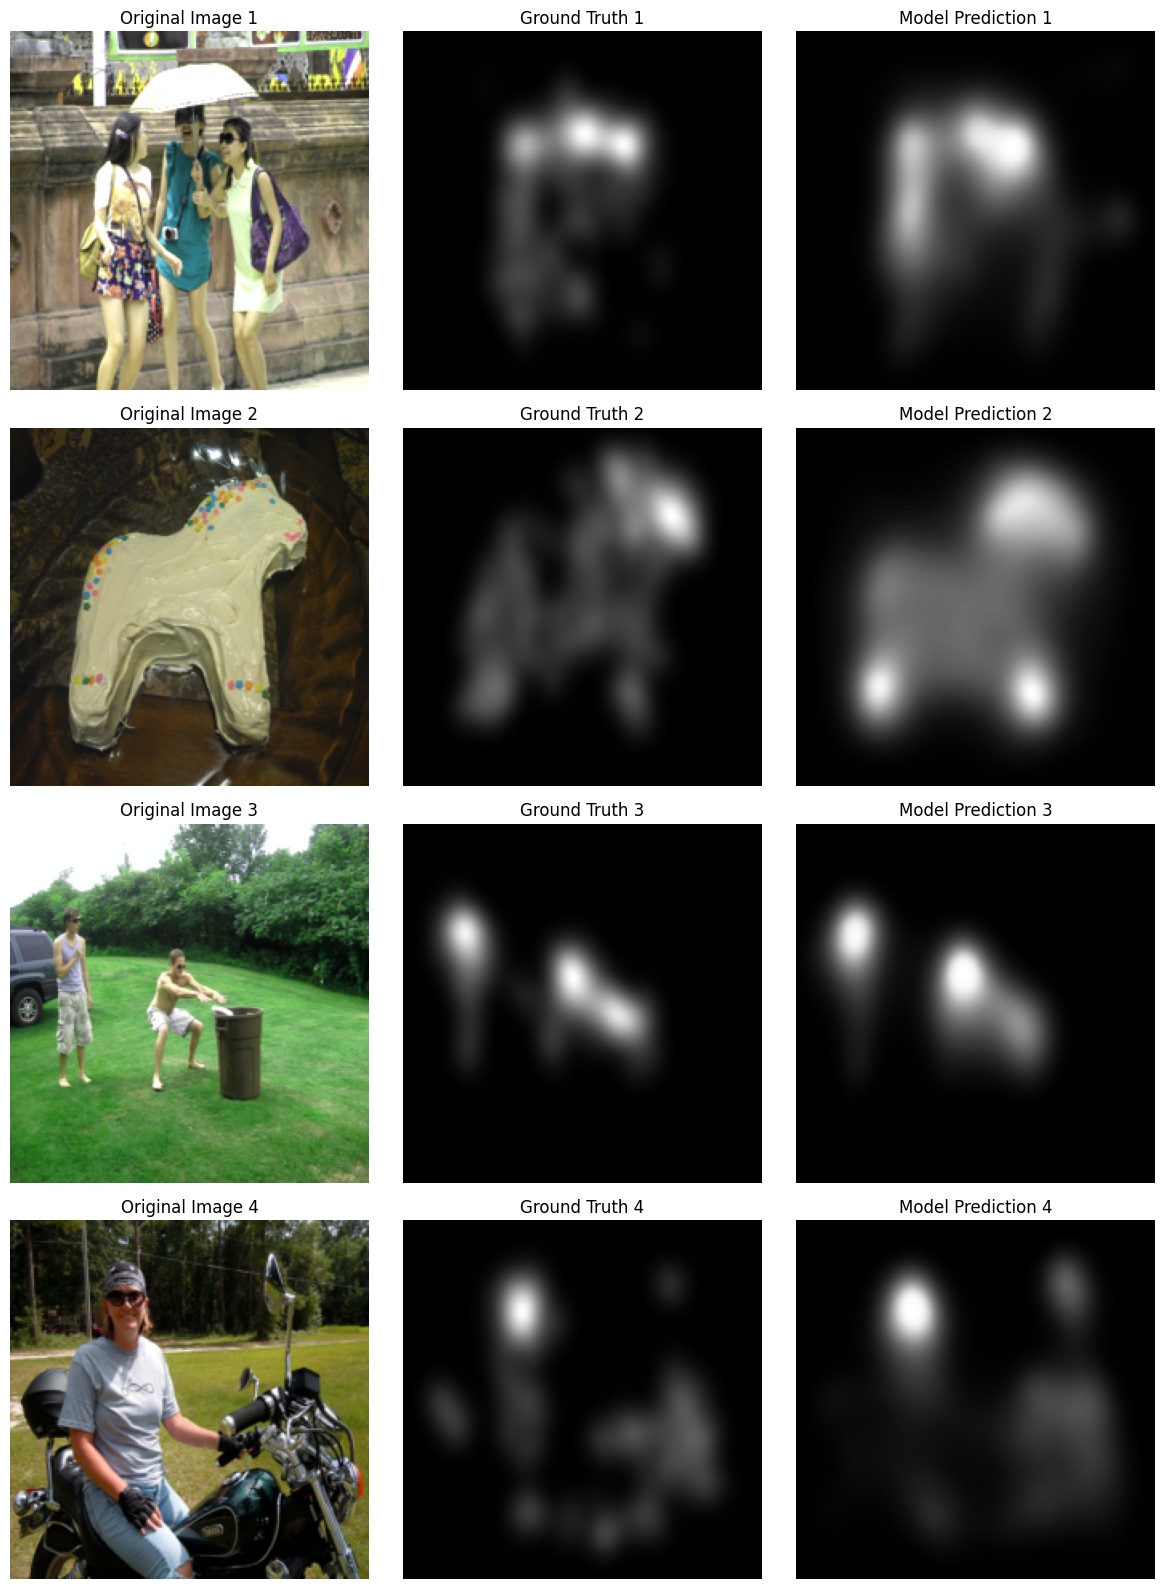

In [11]:
import matplotlib.pyplot as plt
import numpy as np # Import numpy

print("\nGenerating plot...")

import torchvision.transforms.functional as TF
import torch.nn.functional as F

all_images = []
all_gts = []
all_preds = []

scales = [0.8, 1.0, 1.2]
dataiter = iter(test_loader)

while len(all_images) < 8:
    try:
        images, gts = next(dataiter)
    except StopIteration:
        break

    images_device = images.to(device)
    b, c, h, w = images_device.size()

    with torch.no_grad():
        # Empty tensor for ensemble
        ensemble_preds = torch.zeros((b, 1, h, w), device=device)

        # Multi scale TTA for visualization
        for scale in scales:
            if scale != 1.0:
                # Again round to multiples of 32
                scaled_h = int(round((h * scale) / 32.0)) * 32
                scaled_w = int(round((w * scale) / 32.0)) * 32
                scaled_size = (scaled_h, scaled_w)
                images_scaled = F.interpolate(images_device, size=scaled_size, mode='bilinear', align_corners=False)
            else:
                images_scaled = images_device

            # Original and Flipped prediction
            pred_orig = model_loaded(images_scaled)
            images_flipped = torch.flip(images_scaled, dims=[3])
            pred_flipped = model_loaded(images_flipped)

            # Realign and average for current scale
            pred_flipped_back = torch.flip(pred_flipped, dims=[3])
            pred_fused = (pred_orig + pred_flipped_back) / 2.0

            # Resize to base resolution
            if scale != 1.0:
                pred_fused = F.interpolate(pred_fused, size=(h, w), mode='bilinear', align_corners=False)

            ensemble_preds += pred_fused

        # Final average of the scales
        preds_final = ensemble_preds / len(scales)

        # Post processing
        preds_final = TF.gaussian_blur(preds_final, kernel_size=[best_kernel, best_kernel], sigma=[best_sigma, best_sigma])
        preds_final = torch.clamp(preds_final, 0.0, 1.0)

    all_images.append(images.cpu())
    all_gts.append(gts.cpu())
    all_preds.append(preds_final.cpu())

images = torch.cat(all_images, dim=0)
gts = torch.cat(all_gts, dim=0)
preds = torch.cat(all_preds, dim=0)

def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img

num_images = min(4, images.size(0))
fig, axes = plt.subplots(num_images, 3, figsize=(12, 4 * num_images))

for i in range(num_images):
    ax_img = axes[i, 0] if num_images > 1 else axes[0]
    ax_gt = axes[i, 1] if num_images > 1 else axes[1]
    ax_pred = axes[i, 2] if num_images > 1 else axes[2]

    ax_img.imshow(denormalize(images[i]))
    ax_img.set_title(f"Original Image {i+1}")
    ax_img.axis('off')

    ax_gt.imshow(gts[i].squeeze(), cmap='gray')
    ax_gt.set_title(f"Ground Truth {i+1}")
    ax_gt.axis('off')

    ax_pred.imshow(preds[i].squeeze(), cmap='gray')
    ax_pred.set_title(f"Model Prediction {i+1}")
    ax_pred.axis('off')

plt.tight_layout()
plt.show()